
# Prediksi Final Piala Dunia 2026: Spanyol vs Argentina
### Model Hybrid Poisson + Elo (60% / 40%), basis data 5 tahun terakhir

Notebook ini mereplikasi pendekatan hybrid **Poisson Expected Goals (60%) + Elo Rating (40%)**

**Final:** Spanyol vs Argentina — venue netral, tidak ada bonus home advantage.


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'international-football-results-from-1872-to-2017' dataset.
Path to dataset files: /kaggle/input/international-football-results-from-1872-to-2017


In [6]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TEAM_A = "Spain"
TEAM_B = "Argentina"
MATCH_DATE = pd.Timestamp("2026-07-19")
WINDOW_YEARS = 5
NEUTRAL_VENUE = True   # final dimainkan di venue netral -> tidak ada home advantage
DAVIDSON_NU = 0.68      # parameter draw Davidson (1970), sama seperti model referensi
ELO_K = 32
CSV_PATH = "results.csv"


## 1. Muat data pertandingan historis

In [15]:

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"'{CSV_PATH}' tidak ditemukan di folder ini.\n"
    )

df = pd.read_csv(CSV_PATH, parse_dates=["date"])

REQUIRED_COLS = {"date", "home_team", "away_team", "home_score", "away_score"}
missing_cols = REQUIRED_COLS - set(df.columns)
if missing_cols:
    raise ValueError(f"Kolom wajib tidak ada di results.csv: {missing_cols}. Kolom yang tersedia: {list(df.columns)}")

# pastikan skor numerik (kadang ada baris rusak/terbaca sebagai string)
df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")

before = len(df)
df = df.dropna(subset=["date", "home_team", "away_team", "home_score", "away_score"])
dropped = before - len(df)
if dropped:
    print(f"Catatan: {dropped:,} baris dibuang karena tanggal/nama tim/skor kosong atau tidak valid "
          f"(baris seperti ini kalau tidak dibuang akan meracuni perhitungan Elo dengan NaN).")

df = df.sort_values("date").reset_index(drop=True)
since = MATCH_DATE - pd.DateOffset(years=WINDOW_YEARS)
df_window = df[(df["date"] >= since) & (df["date"] <= MATCH_DATE)].copy()

print(f"Data riil dimuat: {len(df):,} total pertandingan valid, {df['date'].min().date()} s/d {df['date'].max().date()}.")
print(f"Window {WINDOW_YEARS} tahun terakhir ({since.date()} s/d {MATCH_DATE.date()}): {len(df_window):,} pertandingan.")

if df["date"].max() < MATCH_DATE - pd.Timedelta(days=60):
    print(f"\n!! PERHATIAN: data terakhir kamu cuma sampai {df['date'].max().date()}, "
          f"jauh sebelum tanggal final ({MATCH_DATE.date()}). Performa Piala Dunia 2026 "
          f"(termasuk semifinal kemarin) kemungkinan BELUM ikut terhitung di window 5 tahun ini.")


Catatan: 4 baris dibuang karena tanggal/nama tim/skor kosong atau tidak valid (baris seperti ini kalau tidak dibuang akan meracuni perhitungan Elo dengan NaN).
Data riil dimuat: 49,505 total pertandingan valid, 1872-11-30 s/d 2026-07-11.
Window 5 tahun terakhir (2021-07-19 s/d 2026-07-19): 5,233 pertandingan.


## 2. Statistik gol per tim (attack / defense strength), window 5 tahun

Attack strength = gol dicetak/laga ÷ rata-rata liga.
Defense strength = gol kebobolan/laga ÷ rata-rata liga (di bawah 1.0 = pertahanan lebih baik dari rata-rata).
Rata-rata liga dihitung dari seluruh pertandingan di window yang sama (bukan angka tetap).


In [8]:

def find_close_team_names(df, team):
    # cari nama tim yang mirip di dataset -> bantu debug kalau ejaan/penamaan beda
    all_names = pd.unique(pd.concat([df["home_team"], df["away_team"]]))
    return sorted([n for n in all_names if team.lower()[:4] in str(n).lower()])

def team_stats_from_data(df_window, df_full, team):
    home = df_window[df_window["home_team"] == team]
    away = df_window[df_window["away_team"] == team]
    matches = len(home) + len(away)
    gf = home["home_score"].sum() + away["away_score"].sum()
    ga = home["away_score"].sum() + away["home_score"].sum()

    if matches == 0:
        candidates = find_close_team_names(df_full, team)
        raise ValueError(
            f"Tidak ada pertandingan '{team}' di window {WINDOW_YEARS} tahun terakhir.\n"
            f"  - Rentang tanggal window: {since.date()} s/d {MATCH_DATE.date()}\n"
            f"  - Rentang tanggal data kamu: {df_full['date'].min().date()} s/d {df_full['date'].max().date()}\n"
            f"  - Nama tim mirip '{team}' yang ADA di data: {candidates if candidates else '(tidak ketemu sama sekali)'}\n"
            f"  Kemungkinan penyebab: (1) nama tim di CSV beda ejaan, (2) data kamu belum sampai "
            f"tanggal {since.date()}, atau (3) kolom 'date' gagal ke-parse jadi datetime."
        )

    return {
        "matches": int(matches),
        "goals_for": int(gf),
        "goals_against": int(ga),
        "gf_per_match": gf / matches,
        "ga_per_match": ga / matches,
    }

stats_a = team_stats_from_data(df_window, df, TEAM_A)
stats_b = team_stats_from_data(df_window, df, TEAM_B)

LEAGUE_AVG_GOALS = (df_window["home_score"].sum() + df_window["away_score"].sum()) / (2 * len(df_window))

stats_df = pd.DataFrame({TEAM_A: stats_a, TEAM_B: stats_b}).T
stats_df


,matches,goals_for,goals_against,gf_per_match,ga_per_match
Spain,67.0000,158.0000,50.0000,2.3582,0.7463
Argentina,68.0000,154.0000,31.0000,2.2647,0.4559


## 3. Submodel Poisson (bobot 60%)

Expected goals (λ) tiap tim = attack tim × defense lawan × rata-rata liga. Tidak ada bonus
home advantage karena venue netral.


In [9]:

def attack_defense(stats, league_avg):
    return {
        "attack": stats["gf_per_match"] / league_avg,
        "defense": stats["ga_per_match"] / league_avg,
    }

ad_a = attack_defense(stats_a, LEAGUE_AVG_GOALS)
ad_b = attack_defense(stats_b, LEAGUE_AVG_GOALS)

lambda_a = ad_a["attack"] * ad_b["defense"] * LEAGUE_AVG_GOALS   # expected goals Spanyol
lambda_b = ad_b["attack"] * ad_a["defense"] * LEAGUE_AVG_GOALS   # expected goals Argentina

print(f"Rata-rata gol liga (baseline, dari window 5 tahun): {LEAGUE_AVG_GOALS:.3f}")
print(f"{TEAM_A}: attack={ad_a['attack']:.3f}  defense={ad_a['defense']:.3f}  ->  lambda={lambda_a:.3f}")
print(f"{TEAM_B}: attack={ad_b['attack']:.3f}  defense={ad_b['defense']:.3f}  ->  lambda={lambda_b:.3f}")


Rata-rata gol liga (baseline, dari window 5 tahun): 1.358
Spain: attack=1.737  defense=0.550  ->  lambda=0.792
Argentina: attack=1.668  defense=0.336  ->  lambda=1.245


In [10]:

def poisson_outcome_probs(lam_a, lam_b, max_goals=10):
    goals = np.arange(0, max_goals + 1)
    pa = poisson.pmf(goals, lam_a)
    pb = poisson.pmf(goals, lam_b)
    score_matrix = np.outer(pa, pb)   # score_matrix[i, j] = P(A mencetak i, B mencetak j)

    p_a_win = np.tril(score_matrix, k=-1).sum()
    p_draw = np.trace(score_matrix)
    p_b_win = np.triu(score_matrix, k=1).sum()

    flat_idx = np.dstack(np.unravel_index(np.argsort(-score_matrix.ravel()), score_matrix.shape))[0]
    top_scorelines = [(f"{i}-{j}", score_matrix[i, j]) for i, j in flat_idx[:5]]

    return p_a_win, p_draw, p_b_win, score_matrix, top_scorelines

p_a_poisson, p_draw_poisson, p_b_poisson, score_matrix, top_scorelines = poisson_outcome_probs(lambda_a, lambda_b)

print(f"POISSON  ->  {TEAM_A} menang: {p_a_poisson:.1%}   Seri: {p_draw_poisson:.1%}   {TEAM_B} menang: {p_b_poisson:.1%}")
print("\nTop 5 skoreline paling mungkin:")
for score, prob in top_scorelines:
    print(f"  {score:<6} {prob:.1%}")


POISSON  ->  Spain menang: 23.6%   Seri: 29.4%   Argentina menang: 46.9%

Top 5 skoreline paling mungkin:
  0-1    16.2%
  0-0    13.0%
  1-1    12.9%
  1-0    10.3%
  0-2    10.1%


## 4. Submodel Elo (bobot 40%), model Davidson (ν = 0.68)

Dihitung ulang dari awal (mulai 1500) mengikuti setiap pertandingan di `results.csv` secara
kronologis, K=32 dengan goal-difference weighting.


In [11]:

def compute_elo_ratings(df, k=ELO_K, start_rating=1500.0):
    ratings = {}

    def expected(ra, rb):
        return 1.0 / (1.0 + 10 ** ((rb - ra) / 400))

    def gd_multiplier(goal_diff):
        if goal_diff <= 1:
            return 1.0
        elif goal_diff == 2:
            return 1.5
        else:
            return (11 + goal_diff) / 8

    for _, row in df.iterrows():
        h, a = row["home_team"], row["away_team"]
        hs, as_ = row["home_score"], row["away_score"]
        rh = ratings.get(h, start_rating)
        ra = ratings.get(a, start_rating)

        exp_h = expected(rh, ra)
        if hs > as_:
            score_h = 1.0
        elif hs == as_:
            score_h = 0.5
        else:
            score_h = 0.0

        mult = gd_multiplier(abs(hs - as_))
        delta = k * mult * (score_h - exp_h)

        ratings[h] = rh + delta
        ratings[a] = ra - delta

    return ratings

all_ratings = compute_elo_ratings(df)   # dihitung dari seluruh histori sampai tanggal final
elo_a = all_ratings.get(TEAM_A, 1500.0)
elo_b = all_ratings.get(TEAM_B, 1500.0)

print(f"{TEAM_A} Elo: {elo_a:.1f}   {TEAM_B} Elo: {elo_b:.1f}   (selisih: {elo_a - elo_b:+.1f})")

if pd.isna(elo_a) or pd.isna(elo_b):
    raise ValueError(
        "Elo hasilnya NaN. Kemungkinan besar masih ada baris dengan skor/tanggal tidak valid "
        "di results.csv yang lolos dari pembersihan data di sel '1. Muat data'. Coba jalankan:\n"
        "  df[df[['home_score','away_score']].isna().any(axis=1)]\n"
        "untuk cek baris yang bermasalah, lalu jalankan ulang notebook dari awal (Restart & Run All)."
    )


Spain Elo: 2208.2   Argentina Elo: 2211.2   (selisih: -3.0)


In [12]:

def davidson_probs(elo_a, elo_b, nu=DAVIDSON_NU):
    dr = elo_a - elo_b
    s = 10 ** (dr / 400)
    denom = s + 1 + nu * np.sqrt(s)
    p_a = s / denom
    p_b = 1 / denom
    p_draw = (nu * np.sqrt(s)) / denom
    return p_a, p_draw, p_b

p_a_elo, p_draw_elo, p_b_elo = davidson_probs(elo_a, elo_b)
print(f"ELO      ->  {TEAM_A} menang: {p_a_elo:.1%}   Seri: {p_draw_elo:.1%}   {TEAM_B} menang: {p_b_elo:.1%}")


ELO      ->  Spain menang: 37.0%   Seri: 25.4%   Argentina menang: 37.6%


## 5. Blend akhir: 60% Poisson + 40% Elo

In [13]:

W_POISSON, W_ELO = 0.6, 0.4

p_a_final = W_POISSON * p_a_poisson + W_ELO * p_a_elo
p_draw_final = W_POISSON * p_draw_poisson + W_ELO * p_draw_elo
p_b_final = W_POISSON * p_b_poisson + W_ELO * p_b_elo

total = p_a_final + p_draw_final + p_b_final
p_a_final, p_draw_final, p_b_final = p_a_final / total, p_draw_final / total, p_b_final / total

summary = pd.DataFrame({
    "Poisson (60%)": [p_a_poisson, p_draw_poisson, p_b_poisson],
    "Elo (40%)": [p_a_elo, p_draw_elo, p_b_elo],
    "Blended": [p_a_final, p_draw_final, p_b_final],
}, index=[f"{TEAM_A} menang", "Seri", f"{TEAM_B} menang"])

summary_pct = summary.map(lambda x: f"{x:.1%}")
print("Hasil prediksi final (dari data riil):\n")
summary_pct


Hasil prediksi final (dari data riil):



,Poisson (60%),Elo (40%),Blended
Spain menang,23.6%,37.0%,29.0%
Seri,29.4%,25.4%,27.8%
Argentina menang,46.9%,37.6%,43.2%


## 6. Visualisasi

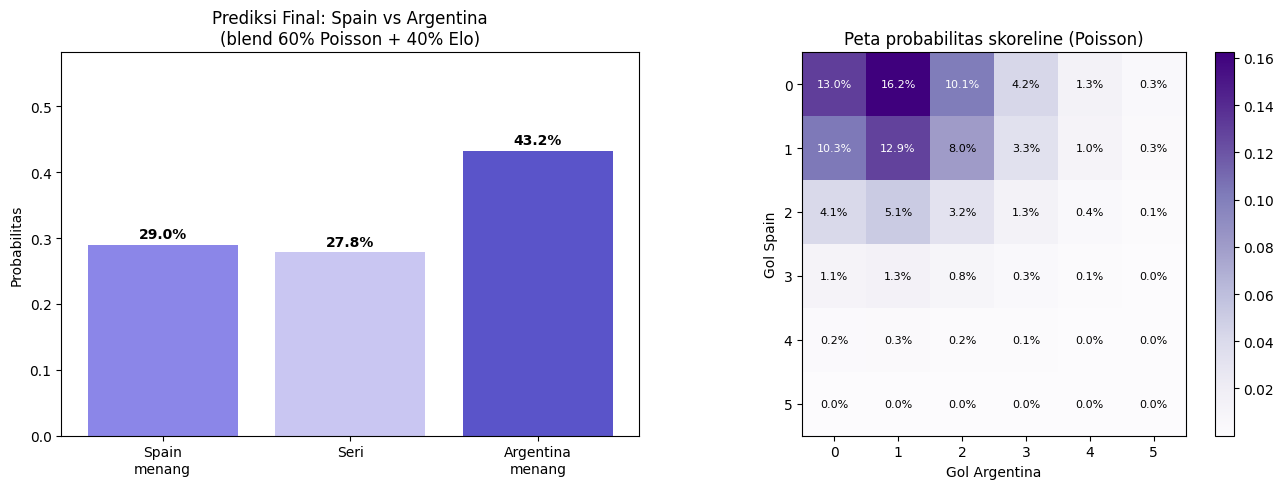

In [14]:

_vals = [p_a_final, p_draw_final, p_b_final]
if any(pd.isna(_vals)):
    raise ValueError(
        f"Ada NaN di probabilitas final: Spain={p_a_final}, Draw={p_draw_final}, Argentina={p_b_final}. "
        "Cek ulang sel '2. Statistik gol per tim' dan '4. Submodel Elo' di atas."
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
labels = [f"{TEAM_A}\nmenang", "Seri", f"{TEAM_B}\nmenang"]
values = [p_a_final, p_draw_final, p_b_final]
colors = ["#8b86e8", "#c9c6f2", "#5a54c9"]
bars = ax.bar(labels, values, color=colors)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_ylim(0, max(values) + 0.15)
ax.set_ylabel("Probabilitas")
ax.set_title(f"Prediksi Final: {TEAM_A} vs {TEAM_B}\n(blend 60% Poisson + 40% Elo)")

ax2 = axes[1]
sub = score_matrix[:6, :6]
im = ax2.imshow(sub, cmap="Purples")
ax2.set_xticks(range(6)); ax2.set_yticks(range(6))
ax2.set_xlabel(f"Gol {TEAM_B}")
ax2.set_ylabel(f"Gol {TEAM_A}")
ax2.set_title("Peta probabilitas skoreline (Poisson)")
for i in range(6):
    for j in range(6):
        ax2.text(j, i, f"{sub[i, j]:.1%}", ha="center", va="center",
                  color="white" if sub[i, j] > sub.max() * 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax2, fraction=0.046)

plt.tight_layout()
plt.savefig("final_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
